In [1]:
import pandas as pd
import numpy as np

print("🔄 Loading Bank Credit Card Data...")

# Load the raw banking dataset
df_credit = pd.read_csv("../data/raw/creditcard.csv")

print(f"✅ Data loaded successfully. Shape: {df_credit.shape[0]} rows, {df_credit.shape[1]} columns\n")

print("--- 🔍 Checking for Missing Values ---")
missing_count = df_credit.isnull().sum().sum()
print(f"Total missing values: {missing_count}")

print("\n--- 👥 Checking for Duplicate Rows ---")
duplicate_count = df_credit.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Drop duplicates to keep the dataset pristine
if duplicate_count > 0:
    print("🔄 Removing duplicate rows...")
    df_credit = df_credit.drop_duplicates().reset_index(drop=True)
    print(f"✅ New Shape: {df_credit.shape[0]} rows, {df_credit.shape[1]} columns")

🔄 Loading Bank Credit Card Data...
✅ Data loaded successfully. Shape: 284807 rows, 31 columns

--- 🔍 Checking for Missing Values ---
Total missing values: 0

--- 👥 Checking for Duplicate Rows ---
Number of duplicate rows found: 1081
🔄 Removing duplicate rows...
✅ New Shape: 283726 rows, 31 columns


In [2]:
print("=== 💳 Bank Credit Card Class Imbalance ===")
counts = df_credit['Class'].value_counts()
percentages = df_credit['Class'].value_counts(normalize=True) * 100

for cls in counts.index:
    label = "Fraudulent" if cls == 1 else "Legitimate"
    print(f"{label} (Class {cls}): {counts[cls]} records ({percentages[cls]:.3f}%)")

=== 💳 Bank Credit Card Class Imbalance ===
Legitimate (Class 0): 283253 records (99.833%)
Fraudulent (Class 1): 473 records (0.167%)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🔄 Separating features and target variable...")
X_bank = df_credit.drop(columns=['Class'])
y_bank = df_credit['Class']

print("🔄 Performing stratified train-test split (80/20)...")
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.2, stratify=y_bank, random_state=42
)

print("🔄 Scaling 'Time' and 'Amount' columns...")
scaler_bank = StandardScaler()

# Copy dataframes to safe variables
X_bank_train_scaled = X_bank_train.copy()
X_bank_test_scaled = X_bank_test.copy()

# Fit only on the training set features to avoid data leakage
columns_to_scale = ['Time', 'Amount']
X_bank_train_scaled[columns_to_scale] = scaler_bank.fit_transform(X_bank_train[columns_to_scale])
X_bank_test_scaled[columns_to_scale] = scaler_bank.transform(X_bank_test[columns_to_scale])

print("✅ Features normalized successfully.")

🔄 Separating features and target variable...
🔄 Performing stratified train-test split (80/20)...
🔄 Scaling 'Time' and 'Amount' columns...
✅ Features normalized successfully.


In [4]:
from imblearn.over_sampling import SMOTE

print("📊 --- Class Distribution BEFORE Banking SMOTE ---")
print(f"Legitimate (Class 0): {np.bincount(y_bank_train)[0]}")
print(f"Fraudulent (Class 1): {np.bincount(y_bank_train)[1]}")

print("\n🔄 Resampling banking minority class via SMOTE...")
smote_bank = SMOTE(random_state=42)
X_bank_train_resampled, y_bank_train_resampled = smote_bank.fit_resample(X_bank_train_scaled, y_bank_train)

print("\n📊 --- Class Distribution AFTER Banking SMOTE ---")
print(f"Legitimate (Class 0): {np.bincount(y_bank_train_resampled)[0]}")
print(f"Fraudulent (Class 1): {np.bincount(y_bank_train_resampled)[1]}")

📊 --- Class Distribution BEFORE Banking SMOTE ---
Legitimate (Class 0): 226602
Fraudulent (Class 1): 378

🔄 Resampling banking minority class via SMOTE...

📊 --- Class Distribution AFTER Banking SMOTE ---
Legitimate (Class 0): 226602
Fraudulent (Class 1): 226602


In [5]:
print("💾 Saving completely processed bank training/testing sets...")

np.savez_compressed('../data/processed/creditcard_train_test.npz', 
                    X_train=X_bank_train_resampled, 
                    X_test=X_bank_test_scaled.values, 
                    y_train=y_bank_train_resampled, 
                    y_test=y_bank_test.values)

print("🎉 Success! All Banking stream components for Task 1 are officially finalized and stored.")

💾 Saving completely processed bank training/testing sets...
🎉 Success! All Banking stream components for Task 1 are officially finalized and stored.


In [1]:
import numpy as np

try:
    cc_data = np.load("../data/processed/creditcard_train_test.npz")
    print("📂 Successfully loaded creditcard_train_test.npz!")
    print("Arrays found:")
    for file in cc_data.files:
        print(f"   - {file}: shape {cc_data[file].shape}")
except Exception as e:
    print(f"❌ Could not load NPZ file: {e}")

📂 Successfully loaded creditcard_train_test.npz!
Arrays found:
   - X_train: shape (453204, 30)
   - X_test: shape (56746, 30)
   - y_train: shape (453204,)
   - y_test: shape (56746,)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# 1. Extract the arrays from your loaded cc_data variable
X_train_cc = cc_data['X_train']
X_test_cc = cc_data['X_test']
y_train_cc = cc_data['y_train']
y_test_cc = cc_data['y_test']

print("--- 💳 Training Credit Card Baseline (Logistic Regression) ---")

# 2. Initialize and train the model
log_reg_cc = LogisticRegression(max_iter=1000, random_state=42)
log_reg_cc.fit(X_train_cc, y_train_cc)

# 3. Make predictions
y_pred_cc = log_reg_cc.predict(X_test_cc)
y_probs_cc = log_reg_cc.predict_proba(X_test_cc)[:, 1] 

# 4. Print Evaluation Metrics
print("\n🎉 Baseline Training Complete! Metrics:")
print("\n1. Confusion Matrix:")
print(confusion_matrix(y_test_cc, y_pred_cc))

print("\n2. Classification Report:")
print(classification_report(y_test_cc, y_pred_cc))

# Calculate Area Under the Precision-Recall Curve (AUC-PR)
precision_cc, recall_cc, _ = precision_recall_curve(y_test_cc, y_probs_cc)
auc_pr_cc = auc(recall_cc, precision_cc)
print(f"3. AUC-PR Score: {auc_pr_cc:.4f}")

--- 💳 Training Credit Card Baseline (Logistic Regression) ---

🎉 Baseline Training Complete! Metrics:

1. Confusion Matrix:
[[55169  1482]
 [   12    83]]

2. Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

3. AUC-PR Score: 0.7150


In [4]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Recover the baseline AUC-PR that got cut off
precision_base, recall_base, _ = precision_recall_curve(y_test_cc, y_probs_cc)
print(f"📉 Recovered Baseline Logistic Regression AUC-PR: {auc(recall_base, precision_base):.4f}\n")

print("--- 🌲 Training Credit Card Model 1: Random Forest ---")
# Capping max_depth ensures it trains swiftly on 450k+ rows
rf_cc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced', n_jobs=-1)
rf_cc.fit(X_train_cc, y_train_cc)

y_pred_rf_cc = rf_cc.predict(X_test_cc)
y_probs_rf_cc = rf_cc.predict_proba(X_test_cc)[:, 1]

print("\n--- ⚡ Training Credit Card Model 2: Gradient Boosting ---")
# Subsampling speeds up Gradient Boosting drastically on large data arrays
gb_cc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, subsample=0.5, random_state=42)
gb_cc.fit(X_train_cc, y_train_cc)

y_pred_gb_cc = gb_cc.predict(X_test_cc)
y_probs_gb_cc = gb_cc.predict_proba(X_test_cc)[:, 1]

# --- Print Side-by-Side Comparisons ---
print("\n=======================================================")
print("         CREDIT CARD ENSEMBLE PERFORMANCE")
print("=======================================================")

print("\n🌲 RANDOM FOREST METRICS:")
print(classification_report(y_test_cc, y_pred_rf_cc))
precision_rf, recall_rf, _ = precision_recall_curve(y_test_cc, y_probs_rf_cc)
print(f"AUC-PR Score: {auc(recall_rf, precision_rf):.4f}")

print("\n⚡ GRADIENT BOOSTING METRICS:")
print(classification_report(y_test_cc, y_pred_gb_cc))
precision_gb, recall_gb, _ = precision_recall_curve(y_test_cc, y_probs_gb_cc)
print(f"AUC-PR Score: {auc(recall_gb, precision_gb):.4f}")

📉 Recovered Baseline Logistic Regression AUC-PR: 0.7150

--- 🌲 Training Credit Card Model 1: Random Forest ---

--- ⚡ Training Credit Card Model 2: Gradient Boosting ---

         CREDIT CARD ENSEMBLE PERFORMANCE

🌲 RANDOM FOREST METRICS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.78      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746

AUC-PR Score: 0.7973

⚡ GRADIENT BOOSTING METRICS:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.12      0.85      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746

AUC-PR Score: 0.7195


In [5]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

print("=======================================================")
print("       CREDIT CARD ENSEMBLE PERFORMANCE (RECOVERED)")
print("=======================================================")

# 1. Print Random Forest Metrics from memory
print("\n🌲 RANDOM FOREST METRICS:")
print(classification_report(y_test_cc, y_pred_rf_cc))
precision_rf, recall_rf, _ = precision_recall_curve(y_test_cc, y_probs_rf_cc)
print(f"AUC-PR Score: {auc(recall_rf, precision_rf):.4f}")

print("\n=======================================================\n")

# 2. Print Gradient Boosting Metrics from memory
print("⚡ GRADIENT BOOSTING METRICS:")
print(classification_report(y_test_cc, y_pred_gb_cc))
precision_gb, recall_gb, _ = precision_recall_curve(y_test_cc, y_probs_gb_cc)
print(f"AUC-PR Score: {auc(recall_gb, precision_gb):.4f}")

       CREDIT CARD ENSEMBLE PERFORMANCE (RECOVERED)

🌲 RANDOM FOREST METRICS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.78      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746

AUC-PR Score: 0.7973


⚡ GRADIENT BOOSTING METRICS:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.12      0.85      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746

AUC-PR Score: 0.7195


📂 Accessing target dataset at: C:\Users\user\fraud-detection\data\processed\creditcard_train_test.npz
✅ Data successfully synchronized! Training structure: (453204, 30)

🌲 Re-training Random Forest Classifier...
✅ Model training finalized! Generating feature insight ranking...


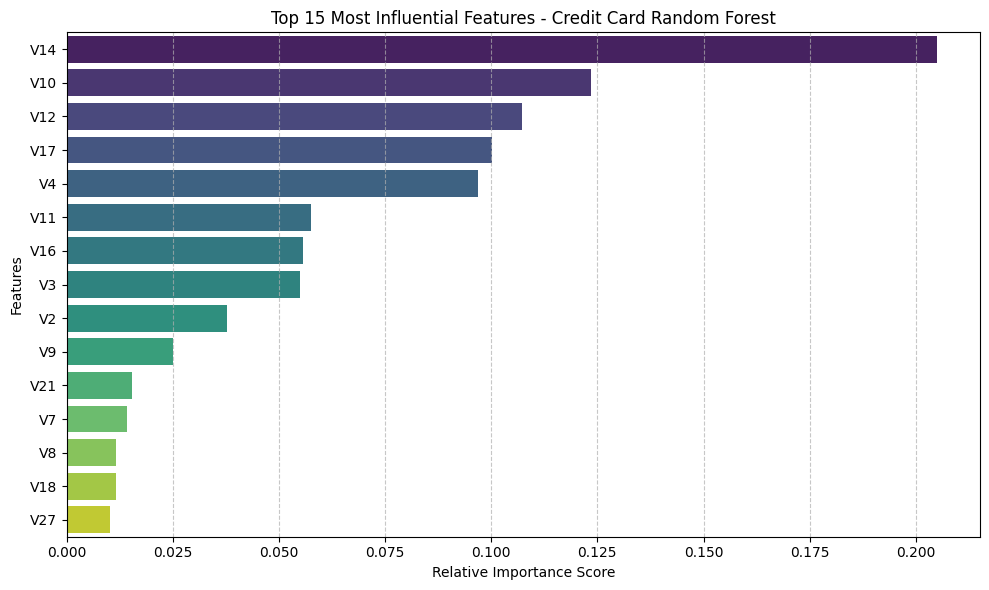

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Point directly to the exact folder discovered by the terminal search
absolute_path = r"C:\Users\user\fraud-detection\data\processed\creditcard_train_test.npz"

print(f"📂 Accessing target dataset at: {absolute_path}")
cc_data = np.load(absolute_path)
X_train_cc = cc_data['X_train']
y_train_cc = cc_data['y_train']
print(f"✅ Data successfully synchronized! Training structure: {X_train_cc.shape}")

print("\n🌲 Re-training Random Forest Classifier...")
# 2. Fast multi-core training configuration
rf_cc_fast = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf_cc_fast.fit(X_train_cc, y_train_cc)
print("✅ Model training finalized! Generating feature insight ranking...")

# 3. Construct column labels mapping to Time, V1-V28, and Amount
feature_names = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
importances = rf_cc_fast.feature_importances_
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 4. Render clean visualization of feature weights (Warning Fix Applied)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=forest_importances.head(15).values, 
    y=forest_importances.head(15).index, 
    hue=forest_importances.head(15).index, 
    palette="viridis", 
    legend=False
)
plt.title("Top 15 Most Influential Features - Credit Card Random Forest")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()